# SuperBooster Causal Impact Notebook

This notebook uses a pure Python workflow:
- Python (`pandas`, `seaborn`) for data wrangling and EDA
- Python (`statsmodels`) for logistic regression and Average Marginal Effects (AME)

## Step 0: Setup
Load Python libraries for wrangling, visualization, and causal-adjusted modeling.

In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

## Step 1: Data Wrangling (Python/Pandas)
- Load data
- Create binary flags (`has_booster`, `churned`) via left joins
- Derive `age` from `dob`
- Fill missing TV/Mobile products with `'None'`
- Encode categoricals for modeling

In [4]:
# Paths assume this notebook is stored under notebooks/
DATA_DIR = "../case_study/Data"

cust = pd.read_csv(f"{DATA_DIR}/cust_details.csv")
booster = pd.read_csv(f"{DATA_DIR}/SuperBooster.csv")
cxl = pd.read_csv(f"{DATA_DIR}/cancellations.csv")

print("cust_details:", cust.shape)
print("SuperBooster:", booster.shape)
print("cancellations:", cxl.shape)

cust_details: (125000, 9)
SuperBooster: (25000, 1)
cancellations: (17657, 1)


In [5]:
# Build treatment/outcome flags from id lists
booster_flag = booster.assign(has_booster=1)[["customer_id", "has_booster"]].drop_duplicates()
churn_flag = cxl.assign(churned=1)[["customer_id", "churned"]].drop_duplicates()

df = cust.merge(booster_flag, on="customer_id", how="left")
df = df.merge(churn_flag, on="customer_id", how="left")

df["has_booster"] = df["has_booster"].fillna(0).astype(int)
df["churned"] = df["churned"].fillna(0).astype(int)

# Age derivation from DOB
df["dob"] = pd.to_datetime(df["dob"], errors="coerce")
reference_date = pd.Timestamp("2026-06-16")
df["age"] = ((reference_date - df["dob"]).dt.days / 365.25).round(1)

# Fill optional products
df["tv_product"] = df["tv_product"].fillna("None")
df["mobile_product"] = df["mobile_product"].fillna("None")

# Standardize text fields
for col in ["internet_usage", "commune", "gender", "tv_product", "mobile_product"]:
    df[col] = df[col].astype(str).str.strip()

# Basic categorical typing for downstream modeling
df["internet_usage"] = pd.Categorical(
    df["internet_usage"],
    categories=["Low", "Medium", "High", "Extreme"],
    ordered=True
)
for col in ["commune", "gender", "tv_product", "mobile_product", "zip"]:
    df[col] = df[col].astype("category")

# One-hot encoded matrix (Python-side modeling readiness)
model_features = ["has_booster", "age", "tenure", "internet_usage", "commune", "gender", "tv_product", "mobile_product", "zip"]
df_model_py = pd.get_dummies(df[model_features], drop_first=True)

print("Analysis table shape:", df.shape)
print("Python model matrix shape:", df_model_py.shape)
df.head()

Analysis table shape: (125000, 12)
Python model matrix shape: (125000, 22)


,customer_id,zip,commune,gender,dob,tenure,internet_usage,tv_product,mobile_product,has_booster,churned,age
0,171647760,7,urban,m,1967-03-17,36,Medium,None,Low,0,0,59.2
1,171651484,8,urban,m,1979-08-27,9,Low,Medium,None,0,1,46.8
2,171632004,4,rural,m,1939-05-20,51,Low,None,None,0,0,87.1
3,171574581,7,rural,m,1937-02-01,46,High,None,Low,0,0,89.4
4,171586949,8,rural,m,1944-11-16,9,Low,Medium,None,0,0,81.6


## Step 2: EDA (Python)
Visualize key pre-treatment differences by booster status to highlight self-selection bias.

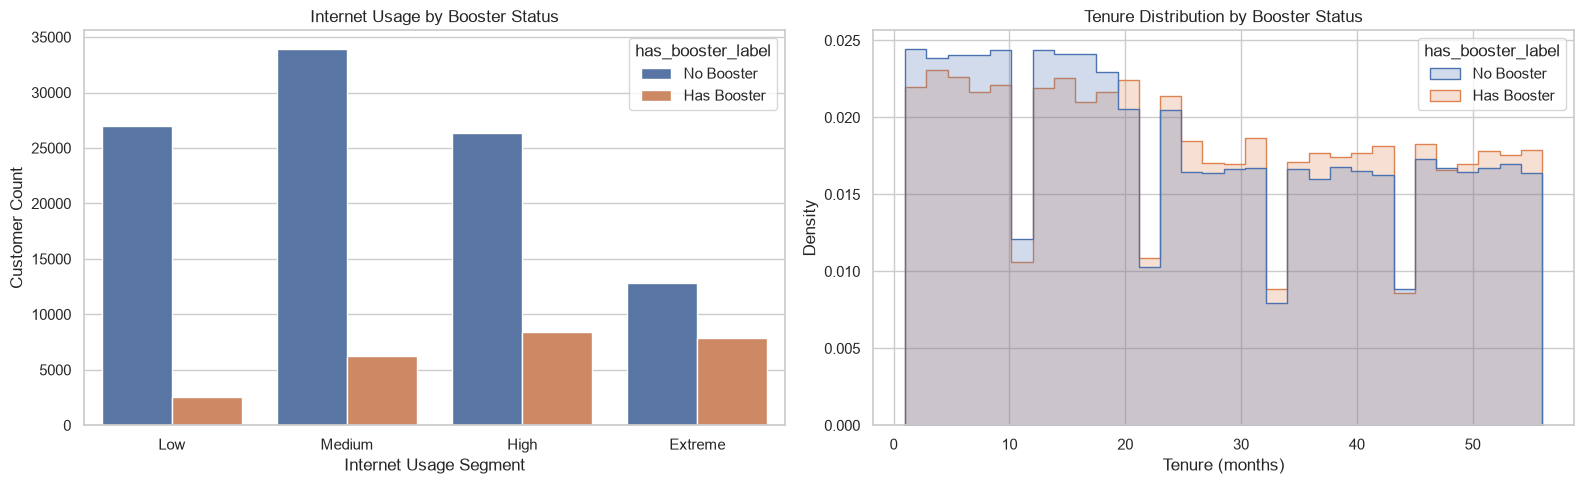

In [6]:
plot_df = df.copy()
plot_df["has_booster_label"] = plot_df["has_booster"].map({0: "No Booster", 1: "Has Booster"})

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(
    data=plot_df,
    x="internet_usage",
    hue="has_booster_label",
    order=["Low", "Medium", "High", "Extreme"],
    ax=axes[0]
)
axes[0].set_title("Internet Usage by Booster Status")
axes[0].set_xlabel("Internet Usage Segment")
axes[0].set_ylabel("Customer Count")

sns.histplot(
    data=plot_df,
    x="tenure",
    hue="has_booster_label",
    bins=30,
    stat="density",
    common_norm=False,
    element="step",
    ax=axes[1]
)
axes[1].set_title("Tenure Distribution by Booster Status")
axes[1].set_xlabel("Tenure (months)")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

## Step 3: Naive Analysis (Python)
Compute raw churn rates without adjustment. This is descriptive, not causal.

In [7]:
naive = (
    df.groupby("has_booster", as_index=False)["churned"]
      .mean()
      .rename(columns={"churned": "churn_rate"})
)
naive["churn_rate_pct"] = (naive["churn_rate"] * 100).round(2)

p1 = naive.loc[naive["has_booster"] == 1, "churn_rate"].iloc[0]
p0 = naive.loc[naive["has_booster"] == 0, "churn_rate"].iloc[0]
delta_naive_pp = (p1 - p0) * 100

display(naive)
print(f"Naive churn gap (Booster - No Booster): {delta_naive_pp:.2f} percentage points")

,has_booster,churn_rate,churn_rate_pct
0,0,0.14530,14.53
1,1,0.12508,12.51


Naive churn gap (Booster - No Booster): -2.02 percentage points


## Step 4: Causal Inference (Python with statsmodels)
Run logistic regression with confounder adjustment and estimate the AME of `has_booster`.

In [13]:
# Keep columns needed in the logistic model and drop rows with missing core fields
model_cols = [
    "churned", "has_booster", "age", "tenure",
    "internet_usage", "commune", "gender",
    "tv_product", "mobile_product", "zip"
]
df_clean = df[model_cols].dropna().copy()

# Ensure categorical dtypes for formula-based encoding
for col in ["internet_usage", "commune", "gender", "tv_product", "mobile_product", "zip"]:
    df_clean[col] = df_clean[col].astype("category")

print("Rows passed to statsmodels model:", len(df_clean))
df_clean.head()

Rows passed to statsmodels model: 125000


,churned,has_booster,age,tenure,internet_usage,commune,gender,tv_product,mobile_product,zip
0,0,0,59.2,36,Medium,urban,m,None,Low,7
1,1,0,46.8,9,Low,urban,m,Medium,None,8
2,0,0,87.1,51,Low,rural,m,None,None,4
3,0,0,89.4,46,High,rural,m,None,Low,7
4,0,0,81.6,9,Low,rural,m,Medium,None,8


In [15]:
formula = (
    "churned ~ has_booster + age + tenure + "
    "C(internet_usage) + C(commune) + C(gender) + "
    "C(tv_product) + C(mobile_product) + C(zip)"
 )

logit_model = smf.logit(formula=formula, data=df_clean).fit(disp=False)

marginal = logit_model.get_margeff(at="overall", method="dydx")
margeff_df = pd.DataFrame({
    "term": marginal.summary_frame().index,
    "dy_dx": marginal.summary_frame()["dy/dx"],
    "std_err": marginal.summary_frame()["Std. Err."],
    "z": marginal.summary_frame()["z"],
    "p_value": marginal.summary_frame()["Pr(>|z|)"],
    "conf_low": marginal.summary_frame()["Conf. Int. Low"],
    "conf_high": marginal.summary_frame()["Cont. Int. Hi."]
}).reset_index(drop=True)

# Keep the same downstream variable name used in Step 5
ame_booster_pp = float(margeff_df.loc[margeff_df["term"] == "has_booster", "dy_dx"].iloc[0])

print(logit_model.summary())
print(f"Adjusted AME of booster (dy/dx): {ame_booster_pp:.6f}")
display(margeff_df.sort_values(by="p_value").head(12))

                           Logit Regression Results                           
Dep. Variable:                churned   No. Observations:               125000
Model:                          Logit   Df Residuals:                   124977
Method:                           MLE   Df Model:                           22
Date:                Tue, 16 Jun 2026   Pseudo R-squ.:                 0.01151
Time:                        13:20:30   Log-Likelihood:                -50319.
converged:                       True   LL-Null:                       -50905.
Covariance Type:            nonrobust   LLR p-value:                3.797e-234
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                       -1.8976      0.052    -36.784      0.000      -1.999      -1.796
C(internet_usage)[T.Medium]     -0.0106      0.022     -0.478      0.633     

,term,dy_dx,std_err,z,p_value,conf_low,conf_high
3,C(commune)[T.urban],0.037743,0.002019,18.692748,5.671545e-78,0.033785,0.041700
10,C(mobile_product)[T.None],0.040567,0.002637,15.385381,2.051642e-53,0.035399,0.045735
20,age,-0.000592,0.000048,-12.324530,6.683188e-35,-0.000686,-0.000498
7,C(tv_product)[T.None],0.026650,0.003438,7.752131,9.036319e-15,0.019912,0.033388
19,has_booster,-0.016211,0.002807,-5.776123,7.644155e-09,-0.021712,-0.010711
21,tenure,0.000256,0.000060,4.275878,1.903853e-05,0.000139,0.000374
12,C(zip)[T.3],0.013872,0.004660,2.976461,2.915959e-03,0.004737,0.023006
2,C(internet_usage)[T.Extreme],0.008361,0.003214,2.601705,9.276149e-03,0.002062,0.014660
18,C(zip)[T.9],-0.012388,0.004858,-2.550028,1.077143e-02,-0.021910,-0.002867
15,C(zip)[T.6],-0.008164,0.004838,-1.687347,9.153659e-02,-0.017646,0.001319


## Step 5: Financial Assessment (Python)
Use the adjusted AME from the statsmodels model as the causal effect and compute rollout economics for 1.5M customers.

In [16]:
N_CUSTOMERS = 1_500_000
VALUE_PER_PREVENTED_CHURN = 1_800.0
BOOSTER_COST = 35.0

# If AME is negative, booster reduces churn; convert to prevented churn rate.
prevented_rate = max(-ame_booster_pp, 0.0)

total_cost = N_CUSTOMERS * BOOSTER_COST
saved_revenue = N_CUSTOMERS * prevented_rate * VALUE_PER_PREVENTED_CHURN
net_roi = saved_revenue - total_cost
break_even_rate = BOOSTER_COST / VALUE_PER_PREVENTED_CHURN

print(f"Prevented churn rate (causal): {prevented_rate * 100:.3f}%")
print(f"Break-even prevented churn rate: {break_even_rate * 100:.3f}%")
print(f"Total rollout cost (CHF): {total_cost:,.0f}")
print(f"Expected revenue saved (CHF): {saved_revenue:,.0f}")
print(f"Net ROI (CHF): {net_roi:,.0f}")

if net_roi > 0:
    print("CCO Recommendation: Universal rollout is financially viable based on adjusted causal effect.")
else:
    print("CCO Recommendation: Universal rollout is NOT financially viable; prefer targeted rollout to high-uplift segments.")

Prevented churn rate (causal): 1.621%
Break-even prevented churn rate: 1.944%
Total rollout cost (CHF): 52,500,000
Expected revenue saved (CHF): 43,770,738
Net ROI (CHF): -8,729,262
CCO Recommendation: Universal rollout is NOT financially viable; prefer targeted rollout to high-uplift segments.
